**IMPORTING LIBRARIES**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

**LOADING DATASET**

In [4]:
df= pd.read_csv('household_power_consumption.txt', sep=';', low_memory=False)

**EXPLORING AND CLEANING DATA SET**

In [5]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [6]:
df.replace("?", np.nan, inplace=True)

In [7]:
columns=['global_active_power',
'global_reactive_power',        
'voltage',                      
'global_intensity' ,            
'sub_metering_1',               
'sub_metering_2' ,              
'sub_metering_3'
        ]      
for col in columns:
    df[col] = pd.to_numeric(df[col])

In [8]:
df.dropna(inplace=True)

In [9]:
df['target_energy']=df['global_active_power']

In [10]:
df["datetime"] = pd.to_datetime(
    df["date"] + " " + df["time"],
    format="%d/%m/%Y %H:%M:%S"
)
df["hour"] = df["datetime"].dt.hour
df["day"] = df["datetime"].dt.day
df["month"] = df["datetime"].dt.month
df["weekday"] = df["datetime"].dt.weekday

In [11]:
df.drop(columns=["date", "time", "target_energy"], inplace=True, errors="ignore")

**Exploratory Data Analysis (EDA)**

In [12]:
# Convert datetime column properly
df["datetime"] = pd.to_datetime(df["datetime"])
df.set_index("datetime", inplace=True)

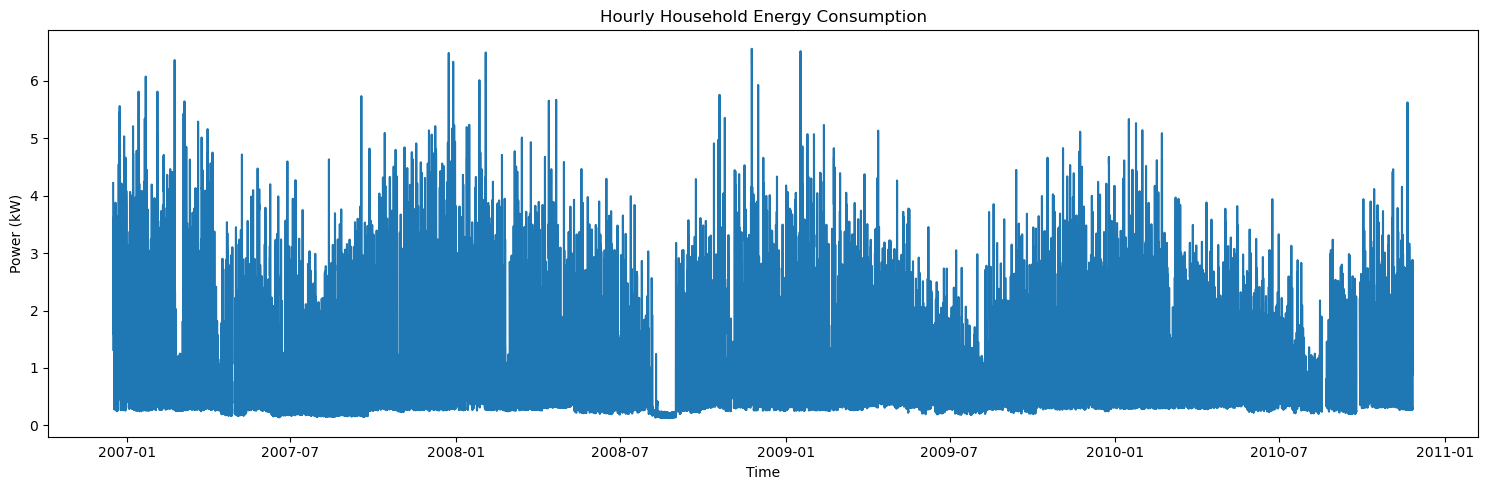

In [13]:
hourly = df["global_active_power"].resample("h").mean()

plt.figure(figsize=(15,5))
plt.plot(hourly.index, hourly)

plt.title("Hourly Household Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Power (kW)")

plt.tight_layout()
plt.show()

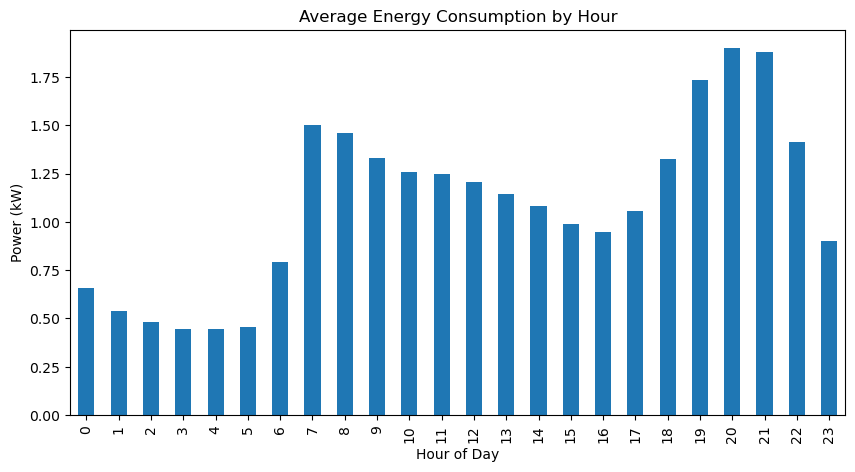

In [14]:
#Hourly Energy Pattern

hourly = df.groupby(df.index.hour)["global_active_power"].mean()
plt.figure(figsize=(10,5))
hourly.plot(kind="bar")
plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Power (kW)")
plt.show()

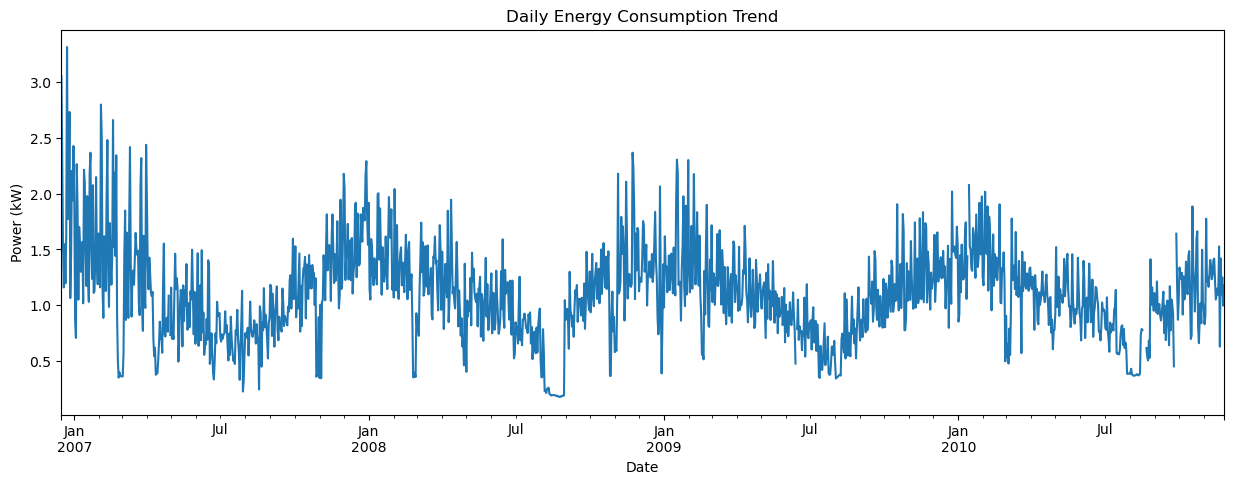

In [15]:
#Daily Pattern
daily = df["global_active_power"].resample("D").mean()

plt.figure(figsize=(15,5))
daily.plot()
plt.title("Daily Energy Consumption Trend")
plt.xlabel("Date")
plt.ylabel("Power (kW)")
plt.show()

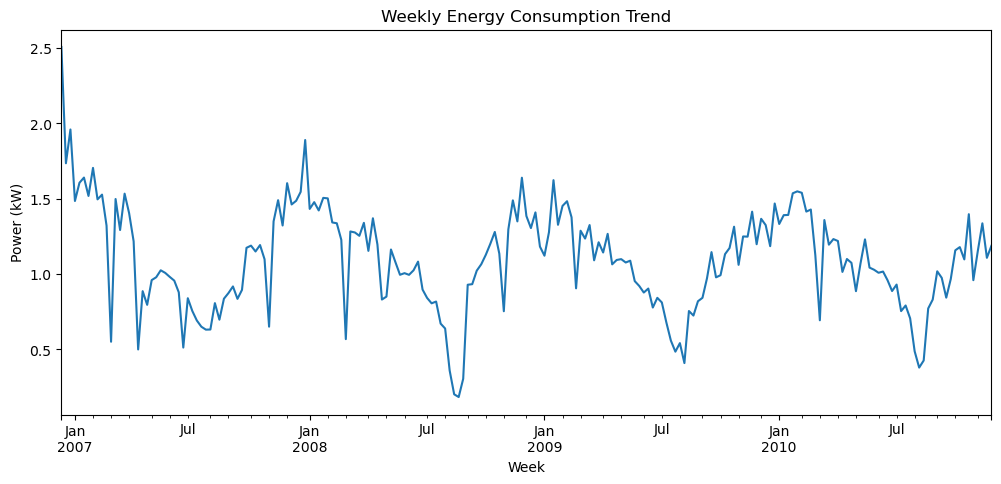

In [16]:
#Weekly Pattern
weekly = df["global_active_power"].resample("W").mean()

plt.figure(figsize=(12,5))
weekly.plot()
plt.title("Weekly Energy Consumption Trend")
plt.xlabel("Week")
plt.ylabel("Power (kW)")
plt.show()

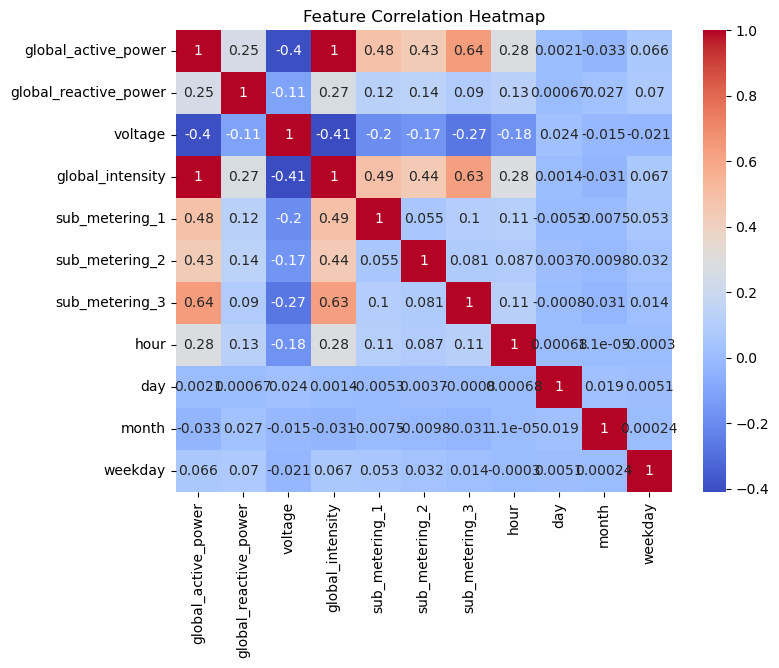

In [17]:
#Correlation Heatmap
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

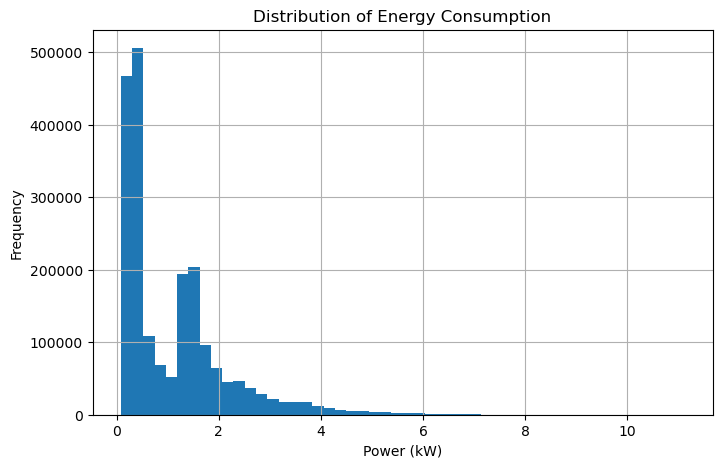

In [18]:
#Distribution of Energy Usage
plt.figure(figsize=(8,5))
df["global_active_power"].hist(bins=50)
plt.title("Distribution of Energy Consumption")
plt.xlabel("Power (kW)")
plt.ylabel("Frequency")
plt.show()

In [19]:
#Peak Load Detection
peak_threshold=df["global_active_power"].quantile(0.95)
peak=df[df["global_active_power"]> peak_threshold]

print("Peak load threshold:", peak_threshold)
print("Number of peak events:", len(peak))

Peak load threshold: 3.264
Number of peak events: 102313


**Feature Engineering**

In [20]:
#Proper sorting
df = df.sort_index()

In [21]:
#Create Lag Features
df["lag_1"] = df["global_active_power"].shift(1)
df["lag_24"] = df["global_active_power"].shift(24)

In [22]:
df["rolling_mean_24"] = df["global_active_power"].rolling(window=24).mean()
df["rolling_mean_168"] = df["global_active_power"].rolling(window=168).mean()

In [23]:
df["hour_sin"] = np.sin(2 * np.pi * df.index.hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * df.index.hour / 24)

df["weekday_sin"] = np.sin(2 * np.pi * df.index.dayofweek / 7)
df["weekday_cos"] = np.cos(2 * np.pi * df.index.dayofweek / 7)

In [24]:
df.dropna(inplace=True)

In [25]:
target = "global_active_power"

In [26]:
#Train/Test Split
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

In [27]:
#Define Features & Target
features = [
    "lag_1",
    "lag_24",
    "rolling_mean_24",
    "rolling_mean_168",
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos"
]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [28]:
#Helper Evaluation Function
def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name} Performance:")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

In [29]:
#Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
evaluate_model(y_test, lr_pred, "Linear Regression")


Linear Regression Performance:
MAE  : 0.0848
RMSE : 0.2192
R²   : 0.9402


In [30]:
#Random Forest Model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

evaluate_model(y_test, rf_pred, "Random Forest")


Random Forest Performance:
MAE  : 0.0955
RMSE : 0.2250
R²   : 0.9370


In [31]:
#XGBoost Model
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

evaluate_model(y_test, xgb_pred, "XGBoost")


XGBoost Performance:
MAE  : 0.0821
RMSE : 0.2178
R²   : 0.9409


In [32]:
#Model Comparison Table
results = {
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],
    "R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ]
}

import pandas as pd

results_df = pd.DataFrame(results)
print(results_df)

               Model       MAE      RMSE        R2
0  Linear Regression  0.084822  0.219203  0.940152
1      Random Forest  0.095520  0.224984  0.936955
2            XGBoost  0.082145  0.217776  0.940929


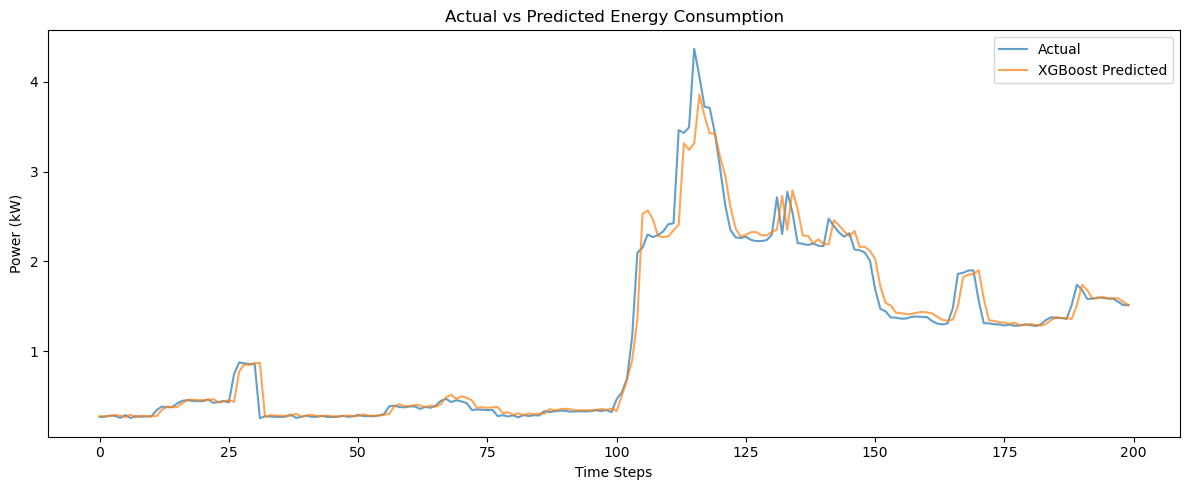

In [33]:
#Visual Comparison
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:200], label="Actual", alpha=0.7)
plt.plot(xgb_pred[:200], label="XGBoost Predicted", alpha=0.7)

plt.title("Actual vs Predicted Energy Consumption")
plt.xlabel("Time Steps")
plt.ylabel("Power (kW)")
plt.legend()

plt.tight_layout()
plt.show()

**Gradient Boosting & XGBoost Comparison**

In [34]:
#Train Gradient Boosting

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbr.fit(X_train, y_train)

gbr_pred = gbr.predict(X_test)

In [35]:
evaluate_model(y_test, gbr_pred, "Gradient Boosting")


Gradient Boosting Performance:
MAE  : 0.0814
RMSE : 0.2169
R²   : 0.9414


In [36]:
#Updated Results Table

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, gbr_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, gbr_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],
    "R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gbr_pred),
        r2_score(y_test, xgb_pred)
    ]
})

results.sort_values("RMSE")

,Model,MAE,RMSE,R2
2,Gradient Boosting,0.081440,0.216883,0.941413
3,XGBoost,0.082145,0.217776,0.940929
0,Linear Regression,0.084822,0.219203,0.940152
1,Random Forest,0.095520,0.224984,0.936955


**Time-Series Cross Validation**

In [37]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

In [38]:
#Grid Search for XGBoost

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1]
}

xgb = XGBRegressor(random_state=42)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
-0.2609362193810063


In [39]:
#Train Best Model

best_xgb = grid.best_estimator_

best_pred = best_xgb.predict(X_test)

evaluate_model(y_test, best_pred, "Tuned XGBoost")


Tuned XGBoost Performance:
MAE  : 0.0820
RMSE : 0.2181
R²   : 0.9408


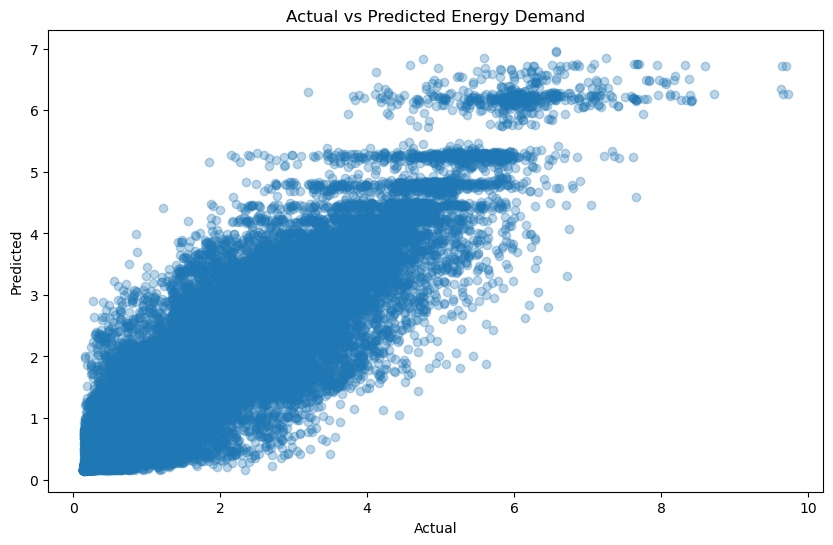

In [40]:
#Predicted vs Actual

plt.figure(figsize=(10,6))

plt.scatter(y_test, best_pred, alpha=0.3)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Energy Demand")

plt.show()

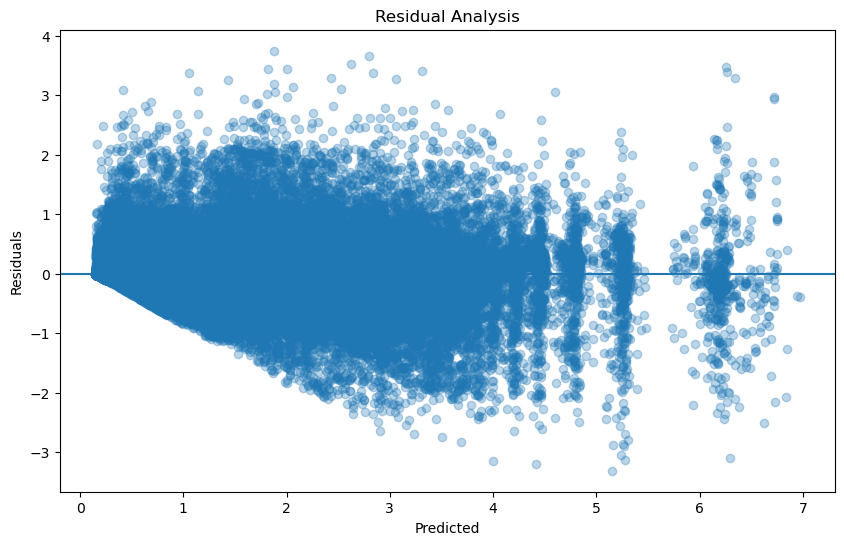

In [41]:
#Residual Plot

residuals = y_test - best_pred

plt.figure(figsize=(10,6))

plt.scatter(best_pred, residuals, alpha=0.3)

plt.axhline(0)

plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.title("Residual Analysis")

plt.show()

In [42]:
#Feature Importance

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

            Feature  Importance
0             lag_1    0.990787
2   rolling_mean_24    0.003091
5          hour_cos    0.001430
4          hour_sin    0.001365
3  rolling_mean_168    0.001257
1            lag_24    0.000857
6       weekday_sin    0.000734
7       weekday_cos    0.000479


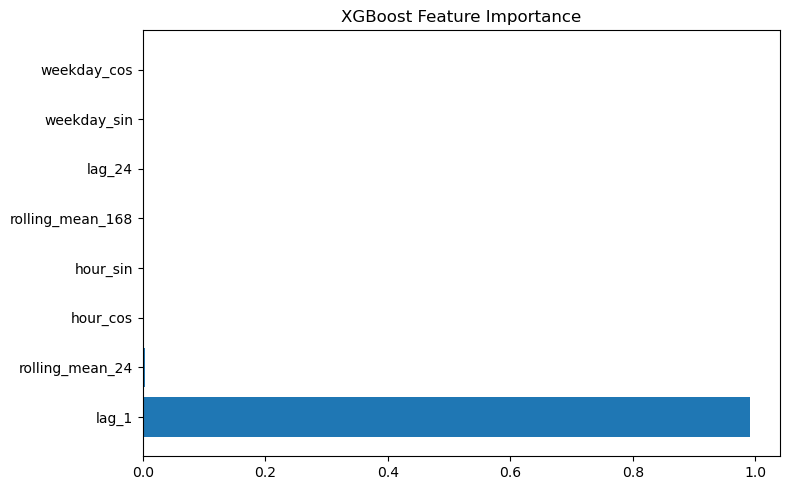

In [43]:
#Visualization

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("XGBoost Feature Importance")

plt.tight_layout()

plt.show()

In [44]:
importance.sort_values(
    "Importance",
    ascending=False
)

,Feature,Importance
0,lag_1,0.990787
2,rolling_mean_24,0.003091
5,hour_cos,0.001430
4,hour_sin,0.001365
3,rolling_mean_168,0.001257
1,lag_24,0.000857
6,weekday_sin,0.000734
7,weekday_cos,0.000479


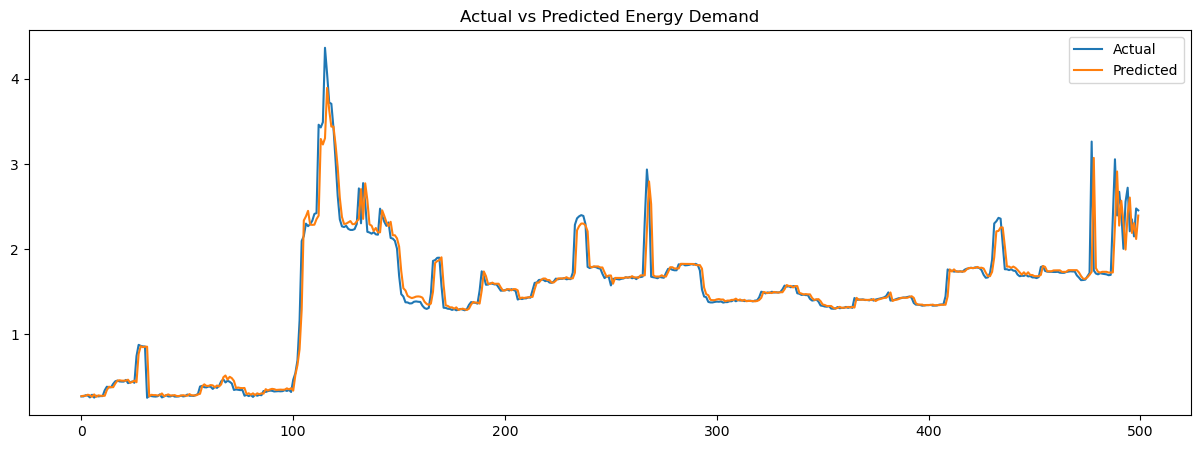

In [45]:
plt.figure(figsize=(15,5))

plt.plot(y_test.iloc[:500].values, label="Actual")
plt.plot(best_pred[:500], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Energy Demand")

plt.show()